# Phase 2 — Exploratory Data Analysis
## Retail Price Elasticity & Promotion Uplift Project

Focus categories: **Eggs** and **Bath Tissues** — chosen for contrast (a highly
homogeneous staple vs. a more brand-differentiated category) across 53 weeks
of transaction data.

Goal of this notebook: understand price and promotion behaviour well enough
to design a defensible elasticity model in Phase 3. In particular, we need
to know whether there's enough independent variation in price and promotion
to actually identify a causal effect, and whether that variation is
confounded by time (seasonality) or by store.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../warehouse.duckdb', read_only=True)

## 1. Pull transaction-level data

Join transactions to products (to filter category) and left-join to
promotions on `(product_id, store_id, week)` — a non-match means the product
was not promoted that week at that store, which is the correct way to
identify the untreated baseline (see `docs/data_dictionary.md`).

In [2]:
query = """
WITH txn AS (
    SELECT t.household_id, t.store_id, t.product_id, t.week,
           t.quantity, t.sales_value, t.unit_price,
           p.product_category,
           COALESCE(pr.is_displayed,0) AS is_displayed,
           COALESCE(pr.is_mailed,0) AS is_mailed
    FROM fact_transactions t
    JOIN dim_product p ON t.product_id = p.product_id
    LEFT JOIN fact_promotions pr
      ON t.product_id = pr.product_id AND t.store_id = pr.store_id AND t.week = pr.week
    WHERE p.product_category IN ('EGGS', 'BATH TISSUES')
)
SELECT * FROM txn
"""
df = con.execute(query).fetchdf()
df['is_promo'] = ((df['is_displayed'] == 1) | (df['is_mailed'] == 1)).astype(int)
print(f"{len(df):,} transaction lines across {df['product_id'].nunique()} products")
df.groupby('product_category').agg(
    transactions=('quantity','count'),
    revenue=('sales_value','sum'),
    avg_price=('unit_price','mean')
).round(2)

24,018 transaction lines across 212 products


,transactions,revenue,avg_price
product_category,,,
BATH TISSUES,8007,34893.87,3.99
EGGS,16011,22402.52,1.18


## 2. Weekly price trend

If price barely moves week to week, there's no variation to estimate an
elasticity from — this is the first thing to check.

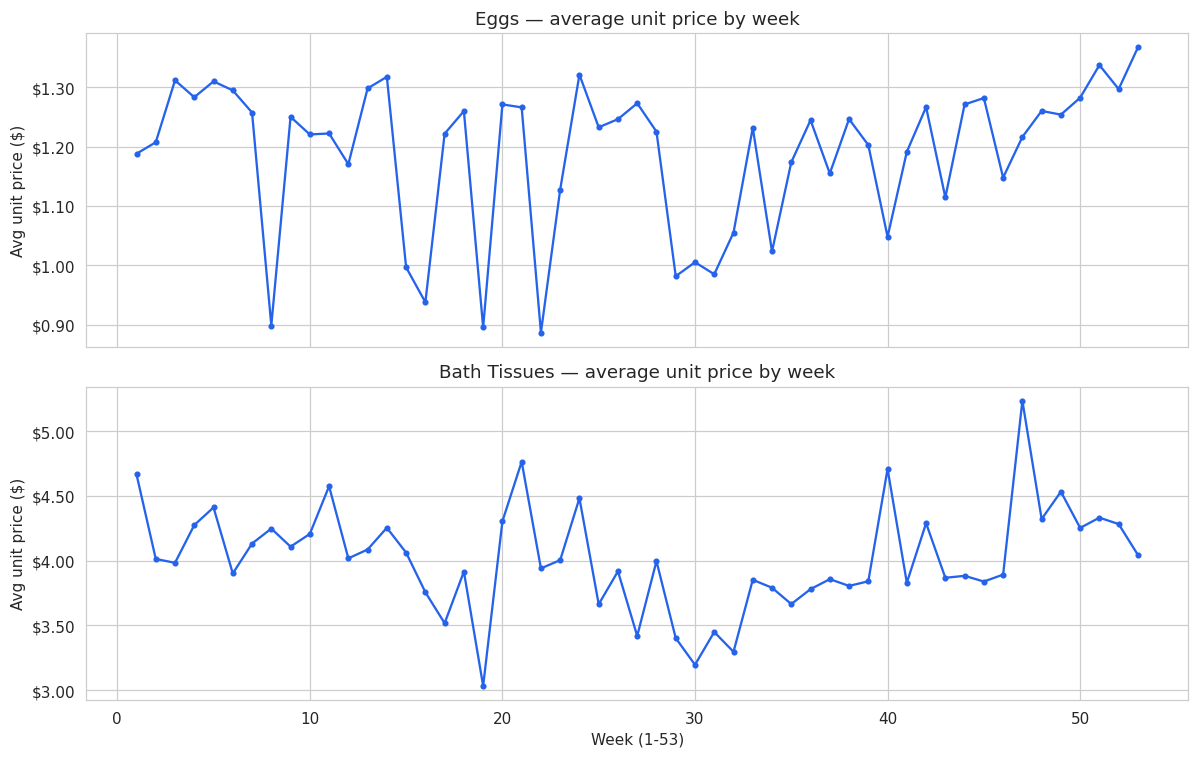

In [3]:
weekly = df.groupby(['product_category','week']).agg(
    avg_price=('unit_price','mean'),
    total_qty=('quantity','sum'),
    n_txn=('quantity','count'),
    promo_rate=('is_promo','mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11,7), sharex=True)
for ax, cat in zip(axes, ['EGGS','BATH TISSUES']):
    sub = weekly[weekly.product_category==cat]
    ax.plot(sub.week, sub.avg_price, marker='o', markersize=3, color='#2563eb')
    ax.set_title(f'{cat.title()} — average unit price by week')
    ax.set_ylabel('Avg unit price ($)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
axes[-1].set_xlabel('Week (1-53)')
plt.tight_layout()
plt.savefig('figures/01_price_trend.png', bbox_inches='tight')
plt.show()

**Reading this:** both categories show real week-to-week price movement —
Eggs swings roughly $1.00–$1.45, Bath Tissues $3.60–$4.90. That's enough
variation to work with, but it's not random: retailers typically cut price
*and* run a display/mailer in the same week, which is exactly the
confound Phase 3 has to untangle.

## 3. Weekly promotion activity

Promotion rate = share of that week's transactions that happened while the
product had an active display or mailer feature at that store.

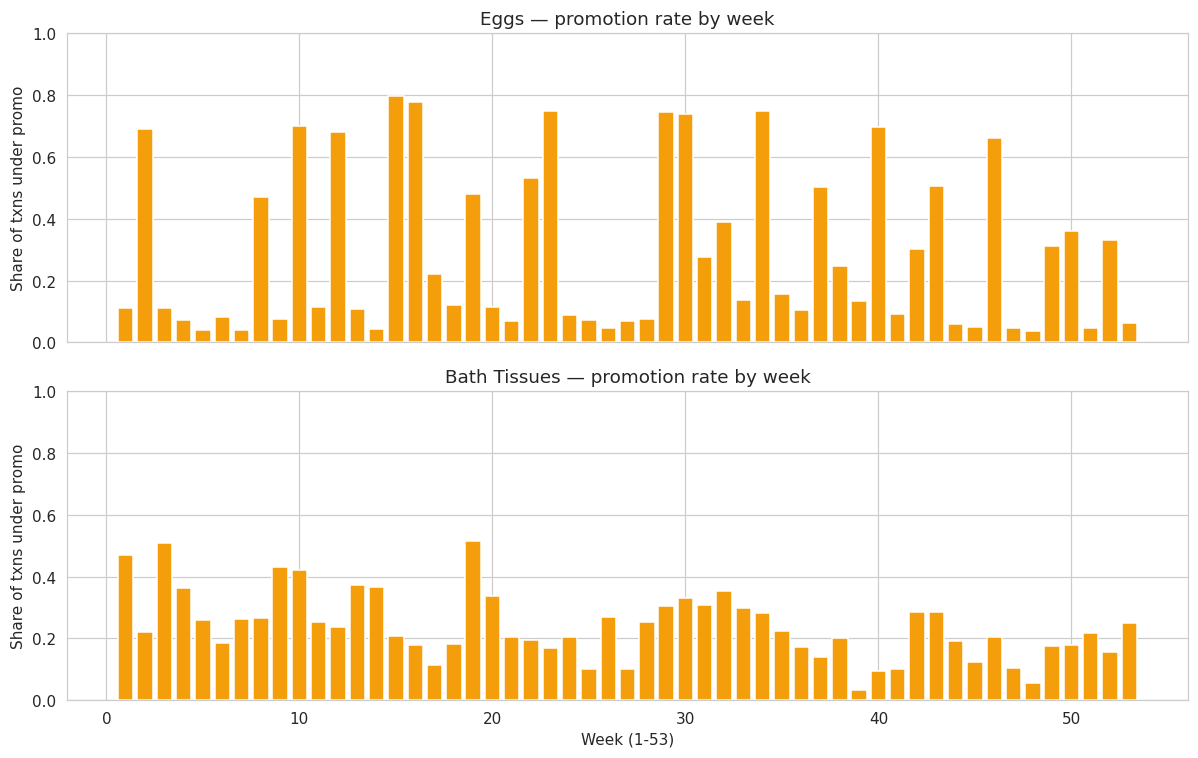

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11,7), sharex=True)
for ax, cat in zip(axes, ['EGGS','BATH TISSUES']):
    sub = weekly[weekly.product_category==cat]
    ax.bar(sub.week, sub.promo_rate, color='#f59e0b', width=0.8)
    ax.set_title(f'{cat.title()} — promotion rate by week')
    ax.set_ylabel('Share of txns under promo')
    ax.set_ylim(0,1)
axes[-1].set_xlabel('Week (1-53)')
plt.tight_layout()
plt.savefig('figures/02_promo_rate_trend.png', bbox_inches='tight')
plt.show()

**Reading this:** promotion activity is lumpy, not constant — both
categories have weeks near 0% promoted and weeks above 60-70%. No obvious
strong seasonal cycle (e.g. no clean holiday spike), but the volatility
itself means week fixed effects will matter in the model — a plain
time-trend won't capture this.

## 4. Does promotion coincide with lower price?

This is the confound directly. If promoted weeks are *also* systematically
the weeks with the lowest price, a simple regression of quantity on price
alone will absorb some of the promotion's effect and overstate the price
elasticity (or vice versa).

/tmp/ipykernel_601/835323434.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='is_promo', y='unit_price', ax=ax, palette=['#94a3b8','#2563eb'])
/tmp/ipykernel_601/835323434.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not promoted','Promoted'])
/tmp/ipykernel_601/835323434.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='is_promo', y='unit_price', ax=ax, palette=['#94a3b8','#2563eb'])


/tmp/ipykernel_601/835323434.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not promoted','Promoted'])


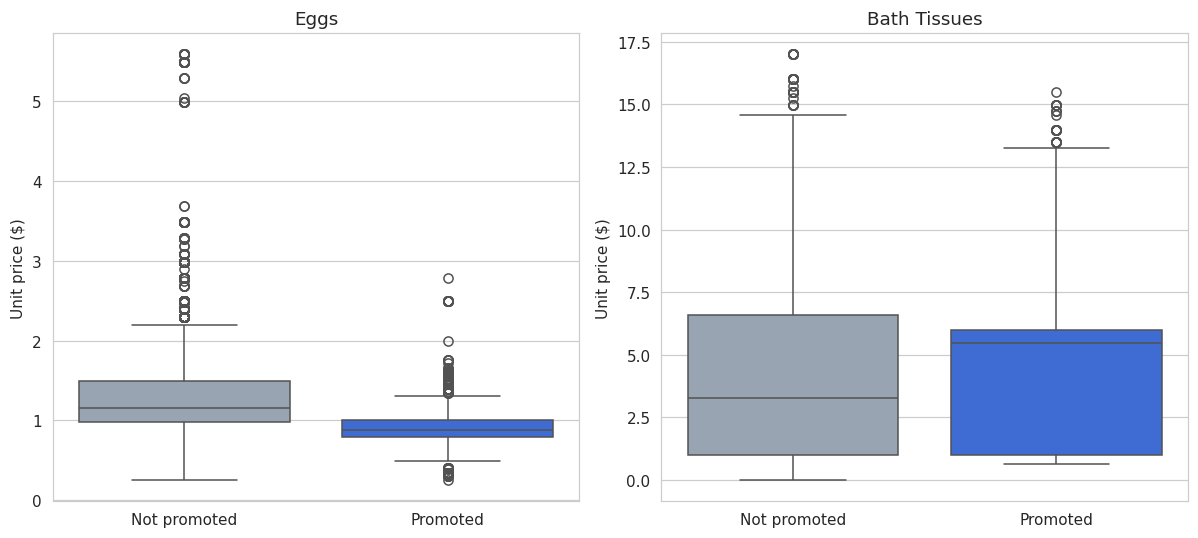

product_category  is_promo
BATH TISSUES      0           3.975
                  1           4.058
EGGS              0           1.309
                  1           0.904
Name: unit_price, dtype: float64

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax, cat in zip(axes, ['EGGS','BATH TISSUES']):
    sub = df[df.product_category==cat]
    sns.boxplot(data=sub, x='is_promo', y='unit_price', ax=ax, palette=['#94a3b8','#2563eb'])
    ax.set_xticklabels(['Not promoted','Promoted'])
    ax.set_title(cat.title())
    ax.set_xlabel('')
    ax.set_ylabel('Unit price ($)')
plt.tight_layout()
plt.savefig('figures/03_price_by_promo_status.png', bbox_inches='tight')
plt.show()

df.groupby(['product_category','is_promo'])['unit_price'].mean().round(3)

In [6]:
df.groupby(['product_category','is_promo'])['unit_price'].agg(['mean','median','count']).round(3)

mean  median  count
product_category is_promo                      
BATH TISSUES     0         3.975    3.29   6105
                 1         4.058    5.49   1902
EGGS             0         1.309    1.16  11000
                 1         0.904    0.88   5011

**Reading this — and this is the more interesting result than the chart
alone suggests:**

- **Eggs behaves as expected**: promoted transactions are cheaper on both
  mean ($0.90 vs $1.31) and median ($0.88 vs $1.16). Straightforward
  confound, same story as the box plot.
- **Bath Tissues does not**: mean price is *similar* between promoted and
  non-promoted ($4.06 vs $3.98), but the median is *higher* when promoted
  ($5.49 vs $3.29). That's a composition effect, not a pricing effect —
  only 41 of the 121 Bath Tissue products are ever promoted at all, and
  those 41 skew toward larger/higher-value pack sizes. The category-level
  comparison is being distorted by *which products* get promoted, not by
  what promotion does to price.

This matters directly for Phase 3: a category-level model would get Bath
Tissues wrong. The elasticity model needs **product-level (SKU) fixed
effects**, not just store/week fixed effects, so each product's promotion
effect is estimated against its own baseline price rather than being
blended with a different mix of products.

## 5. Quantity vs. price — the naive (biased) view

This is what a first-pass "elasticity" would look like if we ignored
everything above and just regressed quantity on price at the weekly level.
Point of this chart is to show *why that would be wrong*, not to report it
as a real result.

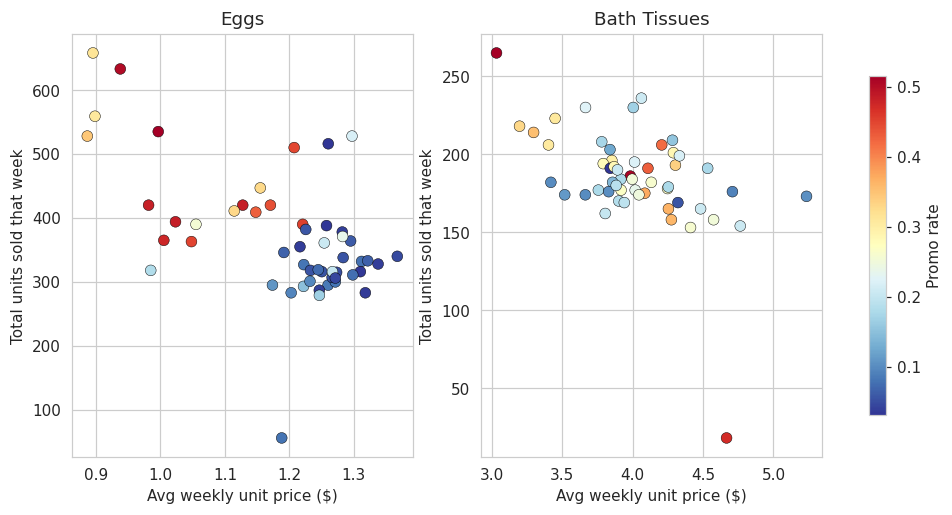

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax, cat in zip(axes, ['EGGS','BATH TISSUES']):
    sub = weekly[weekly.product_category==cat]
    scatter = ax.scatter(sub.avg_price, sub.total_qty, c=sub.promo_rate,
                          cmap='RdYlBu_r', s=50, edgecolor='k', linewidth=0.3)
    ax.set_title(cat.title())
    ax.set_xlabel('Avg weekly unit price ($)')
    ax.set_ylabel('Total units sold that week')
plt.colorbar(scatter, ax=axes, label='Promo rate', shrink=0.8)
plt.savefig('figures/04_quantity_vs_price.png', bbox_inches='tight')
plt.show()

**Reading this:** the highest-volume weeks (top of each chart) are
consistently the reddest points — i.e. the weeks with both low price *and*
high promotion. A naive price-quantity regression here would credit price
alone for a demand spike that promotion likely caused (or vice versa).
This is the textbook price-endogeneity problem and is exactly what Phase 3
needs to address econometrically — most likely with store and week fixed
effects, and price/promotion entered as separate terms rather than
collapsed into one.

## 6. Cross-store variation

Different stores may run different everyday prices for the same product,
independent of promotion — that's a separate, useful source of identifying
variation for the elasticity model (it isn't confounded with the
time-varying promo confound above).

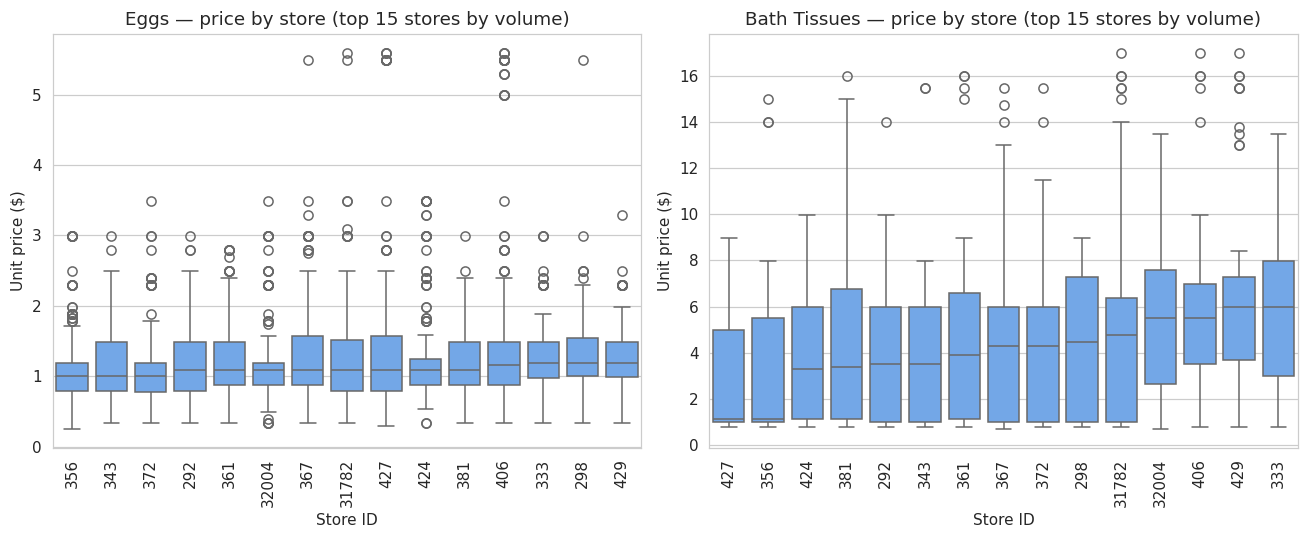

In [8]:
top_stores = (df[df.product_category=='EGGS']
              .groupby('store_id')['quantity'].count()
              .sort_values(ascending=False).head(15).index)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, cat in zip(axes, ['EGGS','BATH TISSUES']):
    sub = df[(df.product_category==cat) & (df.store_id.isin(top_stores))]
    order = sub.groupby('store_id')['unit_price'].median().sort_values().index
    sns.boxplot(data=sub, x='store_id', y='unit_price', order=order, ax=ax, color='#60a5fa')
    ax.set_title(f'{cat.title()} — price by store (top 15 stores by volume)')
    ax.set_xlabel('Store ID')
    ax.set_ylabel('Unit price ($)')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('figures/05_price_by_store.png', bbox_inches='tight')
plt.show()

**Caveat before reading too much into this:** each store's box above
mixes together every product in the category, so part of what looks like
"store variation" is really the same product-mix effect from Section 4 —
some stores may simply carry more of the pricier pack sizes. This chart
alone isn't clean evidence of store-level pricing policy.

The question that actually matters for identification: once you hold the
*same product* fixed, is there still meaningful price variation left
across stores and weeks? That's what the elasticity model will actually
run on.

In [9]:
within_product_std = df.groupby(['product_category','product_id'])['unit_price'].std().groupby('product_category').mean()
within_product_std.round(3)

product_category
BATH TISSUES    0.557
EGGS            0.119
Name: unit_price, dtype: float64

**Reading this:** yes — for a fixed product, the average store/week
price still varies by about **$0.12 (Eggs)** and **$0.56 (Bath Tissues)**.
That's the real source of identifying variation once product fixed effects
are in the model: not "which store is generally cheaper," but "how does
the same product's price move across stores and weeks, and how does
quantity respond." Small but genuinely present — consistent with proceeding
to Phase 3, though the Eggs elasticity estimate will likely have wider
confidence intervals given the smaller within-product price movement.

## 7. Takeaways for Phase 3 modelling

- **Enough price variation to work with**: both categories show meaningful
  week-to-week and store-to-store price movement — an elasticity estimate
  is feasible.
- **Promotion is a real, material confound**: promoted weeks are
  systematically cheaper. Price and promotion status must be entered as
  separate regressors, not treated as one signal.
- **Week fixed effects are necessary**: promotion activity is volatile
  week-to-week with no clean seasonal pattern to model parametrically —
  fixed effects handle this more safely than a smooth time trend.
- **Store fixed effects are worth including**: persistent store-level price
  differences give a second, largely promotion-independent source of price
  variation, and control for store-specific demand levels.
- **Product (SKU) fixed effects are required, not optional**: Section 4
  showed a category-level promo/price comparison can point the wrong
  direction (Bath Tissues) purely because of which products get promoted.
  Pooling to the category level would bias the elasticity estimate.
- **Planned Phase 3 spec**: log(quantity) ~ log(price) + is_displayed +
  is_mailed + product fixed effects + store fixed effects + week fixed
  effects, estimated per category, with product-level effects allowed to
  vary (interaction terms) if individual products show materially
  different responses once the pooled model is fit.